# Raconteur host health -- is the NAS happy?

Reads the **actual hardware and OS values** off Raconteur (`raconteur.ad.local.symmatree.com`,
a Synology RS1619xs+) and judges whether the box is healthy -- not merely whether telemetry
is arriving. Everything is in **Mimir**: Synology SNMP (`job="integrations/snmp/raconteur"`)
for hardware, and node_exporter (`job="integrations/node_exporter"`) for OS resources.

Motivated by what actually makes a NAS unhappy:
- **Disks**: a disk failed/degraded, SMART errors or bad sectors accumulating, an SSD wearing out (remaining-life), a disk running hot.
- **Storage**: a RAID/volume degraded or crashed, or a volume filling up.
- **Environment**: overheating, a failed fan, a power-supply fault.
- **UPS**: on battery, low runtime, or needs a new battery.
- **OS**: CPU/memory/load pressure.

**"Is the edge even delivering?"** is *not* a separate notebook -- it is one **assumptions
gate** here: if the SNMP/node_exporter data is stale, we cannot assess the host and say so
(go look at the edge Alloy per [docs/synology-monitoring.md](../docs/synology-monitoring.md)).
This supersedes the ingestion-first split originally planned in
[#652](https://github.com/symmatree/tiles/issues/652); "did the signal get through" is an
assumption, not a thesis, and if a stream's silence is ever a real invariant it belongs in an
alert rule, not a notebook finding.

Status codes are decoded per the Synology MIB (`SYNOLOGY-{SYSTEM,DISK,RAID}-MIB`); string
fields arrive as hex-encoded OctetStrings and are decoded inline. Thresholds are heuristic
(labeled `chosen`) -- Synology publishes no mixin.

Design: [tiles#652](https://github.com/symmatree/tiles/issues/652) (parent
[#644](https://github.com/symmatree/tiles/issues/644)), [docs/notebooks.md](../docs/notebooks.md).

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace raconteur-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # SNMP + node_exporter both land in Mimir
tenant = "tiles"           # X-Scope-OrgID
edge_cluster = "bond"      # OTLP attributes.cluster on the edge metrics
edge_instance = "raconteur"  # node_exporter instance label
lookback_hours = 24
range_step_s = 300
metric_stale_s = 900       # chosen (no mixin): SNMP/node_exporter are fixed-interval scrapes;
                           # staler than this = data not arriving, host is unassessable
disk_temp_warn_c = 50      # chosen: Synology flags disk temp in the high-40s/50s
sys_temp_warn_c = 70       # chosen: system/board temperature ceiling
ssd_life_warn_pct = 20     # chosen: SSD remaining-life below this = wearing out (watch)
vol_full_warn_pct = 85     # chosen: volume fullness watch
vol_full_crit_pct = 95     # chosen: volume fullness critical
ups_runtime_warn_s = 300   # chosen: UPS battery runtime floor (5 min)
capture_file = ""          # replay a prior raw capture JSON instead of querying live
output_dir = ""            # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'raconteur-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, tenant=tenant,
                  edge_cluster=edge_cluster, edge_instance=edge_instance,
                  lookback_hours=lookback_hours, range_step_s=range_step_s,
                  metric_stale_s=metric_stale_s)
tenant = cap.meta['tenant']
edge_cluster, edge_instance = cap.meta['edge_cluster'], cap.meta['edge_instance']
lookback_hours, step = cap.meta['lookback_hours'], cap.meta['range_step_s']
metric_stale_s = cap.meta['metric_stale_s']
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)


def hexdec(s):
    """Synology OctetString labels arrive as '0x...'; decode to text (DisplayStrings pass through)."""
    if isinstance(s, str) and s.startswith('0x'):
        try:
            return bytes.fromhex(s[2:]).decode('utf-8', 'replace').strip('\x00').strip()
        except ValueError:
            return s
    return s


def idx_val(res, idx):
    """Numeric SNMP table metric -> {index-label: float}."""
    return {r['metric'].get(idx, ''): float(r['value'][1]) for r in res}


def idx_lbl(res, idx, lbl):
    """String SNMP table metric (value in a same-named label) -> {index-label: decoded text}."""
    return {r['metric'].get(idx, ''): hexdec(r['metric'].get(lbl, '')) for r in res}


# Synology MIB status decodes (SYNOLOGY-SYSTEM-MIB / DISK-MIB / RAID-MIB). 1 = healthy throughout.
SYS_STATUS = {1: 'Normal', 2: 'Failed'}
UPGRADE = {1: 'Available', 2: 'Unavailable', 3: 'Connecting', 4: 'Disconnected', 5: 'Others'}
DISK_STATUS = {1: 'Normal', 2: 'Initialized', 3: 'NotInitialized', 4: 'SystemPartitionFailed', 5: 'Crashed'}
DISK_HEALTH = {1: 'Normal', 2: 'Warning', 3: 'Critical', 4: 'Failing'}
RAID_STATUS = {1: 'Normal', 2: 'Repairing', 3: 'Migrating', 4: 'Expanding', 5: 'Deleting',
               6: 'Creating', 7: 'RaidSyncing', 8: 'RaidParityChecking', 9: 'RaidAssembling',
               10: 'Canceling', 11: 'Degrade', 12: 'Crashed', 13: 'DataScrubbing',
               14: 'RaidDeploying', 15: 'RaidUnDeploying', 16: 'RaidMountCache',
               17: 'RaidUnmountCache', 18: 'RaidExpandingUnfinishedSHR',
               19: 'RaidConvertSHRToPool', 20: 'RaidMigrateSHR1ToSHR2', 21: 'RaidUnknownStatus'}
print(f"mimir: {cap.meta['mimir_url']}  tenant: {tenant}  edge: {edge_cluster}/{edge_instance}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  tenant: tiles  edge: bond/raconteur  live


In [3]:
# --- ASSUMPTIONS: the ONE data-through gate (this is what the ingestion notebook collapses to) ---
# Is the edge delivering fresh data? If not, we cannot read the host's values -- say so and
# stop. This is an assumption, not a thesis: no per-stream tables, no invented findings.
INSTR_STALE_S = 600
sn = f'cluster="{edge_cluster}"'
ne = f'cluster="{edge_cluster}", instance="{edge_instance}"'

mimir_ts = nbc.val(mm.q('instr: mimir up', 'max(timestamp(up))'))
mimir_age = cap.now - mimir_ts if not np.isnan(mimir_ts) else np.inf
snmp_ts = nbc.val(mm.q('fresh: snmp', f'max(timestamp(up{{{sn}, job="integrations/snmp/raconteur"}}))'))
snmp_age = cap.now - snmp_ts if not np.isnan(snmp_ts) else np.inf
ne_ts = nbc.val(mm.q('fresh: node_exporter', f'max(timestamp(node_cpu_seconds_total{{{ne}}}))'))
ne_age = cap.now - ne_ts if not np.isnan(ne_ts) else np.inf

def _id(metric, lbl):
    r = mm.q(f'id: {lbl}', f'{metric}{{{sn}}}')
    return hexdec(r[0]['metric'].get(lbl, '')) if r else ''
model = _id('modelName', 'modelName')
dsm_version = _id('version', 'version').removeprefix('DSM ')  # value is "DSM 7.3-..."; keep the number
serial = _id('serialNumber', 'serialNumber')
boot = nbc.val(mm.q('boot', f'node_boot_time_seconds{{{ne}}}'))
uptime_d = (cap.now - boot) / 86400 if not np.isnan(boot) else float('nan')

print("=== ASSUMPTIONS (data-through gate) ===")
for name, age in [('mimir serving (up)', mimir_age), ('snmp scrape', snmp_age), ('node_exporter', ne_age)]:
    print(f"  {name:<22} {'MISSING' if np.isinf(age) else f'{age:.0f}s old'}")
if np.isinf(mimir_age) or mimir_age > INSTR_STALE_S:
    raise RuntimeError(f"unassessable: Mimir not serving fresh data ({mimir_age:.0f}s) -- see mimir-health.ipynb")
if (np.isinf(snmp_age) or snmp_age > metric_stale_s) and (np.isinf(ne_age) or ne_age > metric_stale_s):
    raise RuntimeError(f"unassessable: raconteur is not delivering metrics (snmp {snmp_age:.0f}s, "
                       f"node_exporter {ne_age:.0f}s, both > {metric_stale_s}s) -- suspect the edge Alloy / "
                       "OTLP path (docs/synology-monitoring.md). This notebook reads host VALUES; it needs fresh data.")
if np.isinf(snmp_age) or snmp_age > metric_stale_s:
    print(f"  WARNING: SNMP stale ({snmp_age:.0f}s) -- hardware sections may be stale")
if np.isinf(ne_age) or ne_age > metric_stale_s:
    print(f"  WARNING: node_exporter stale ({ne_age:.0f}s) -- OS sections may be stale")
print(f"  host: {model}  DSM {dsm_version}  serial {serial}  uptime {uptime_d:.1f}d")

=== ASSUMPTIONS (data-through gate) ===
  mimir serving (up)     2s old
  snmp scrape            12s old
  node_exporter          45s old
  host: RS1619xs+  DSM 7.3-86009  serial 1930QPRZYQZR1  uptime 4.9d


In [4]:
# --- CAPTURE: fetch the complete raw observation up front ---
sn = f'cluster="{edge_cluster}"'                       # SNMP metrics carry only cluster (+ job)
ne = f'cluster="{edge_cluster}", instance="{edge_instance}"'  # node_exporter carries instance

# System & environment (single-series gauges; kept as floats -- dict.get(1.0) matches key 1)
sys_status = nbc.val(mm.q('systemStatus', f'systemStatus{{{sn}}}'))
power_status = nbc.val(mm.q('powerStatus', f'powerStatus{{{sn}}}'))
sys_fan = nbc.val(mm.q('systemFanStatus', f'systemFanStatus{{{sn}}}'))
cpu_fan = nbc.val(mm.q('cpuFanStatus', f'cpuFanStatus{{{sn}}}'))
sys_temp = nbc.val(mm.q('temperature', f'temperature{{{sn}}}'))
upgrade = nbc.val(mm.q('upgradeAvailable', f'upgradeAvailable{{{sn}}}'))

# Disks (by diskIndex)
d_status = idx_val(mm.q('diskStatus', f'diskStatus{{{sn}}}'), 'diskIndex')
d_health = idx_val(mm.q('diskHealthStatus', f'diskHealthStatus{{{sn}}}'), 'diskIndex')
d_temp = idx_val(mm.q('diskTemperature', f'diskTemperature{{{sn}}}'), 'diskIndex')
d_life = idx_val(mm.q('diskRemainLife', f'diskRemainLife{{{sn}}}'), 'diskIndex')
d_bad = idx_val(mm.q('diskBadSector', f'diskBadSector{{{sn}}}'), 'diskIndex')
d_retry = idx_val(mm.q('diskRetry', f'diskRetry{{{sn}}}'), 'diskIndex')
d_name = idx_lbl(mm.q('diskName', f'diskName{{{sn}}}'), 'diskIndex', 'diskName')
d_model = idx_lbl(mm.q('diskModel', f'diskModel{{{sn}}}'), 'diskIndex', 'diskModel')
d_type = idx_lbl(mm.q('diskType', f'diskType{{{sn}}}'), 'diskIndex', 'diskType')

# SMART: flat table keyed by diskSMARTInfoIndex; status 1 = OK. Join name/device for any bad.
smart_res = mm.q('diskSMARTAttrStatus', f'diskSMARTAttrStatus{{{sn}}}')
smart_total = len(smart_res)
smart_ok = sum(1 for r in smart_res if float(r['value'][1]) == 1)
smart_bad_idx = [r['metric'].get('diskSMARTInfoIndex', '') for r in smart_res if float(r['value'][1]) != 1]
smart_names = {r['metric'].get('diskSMARTInfoIndex', ''): hexdec(r['metric'].get('diskSMARTAttrName', ''))
               for r in mm.q('diskSMARTAttrName', f'diskSMARTAttrName{{{sn}}}')}
smart_dev = {r['metric'].get('diskSMARTInfoIndex', ''): hexdec(r['metric'].get('diskSMARTInfoDevName', ''))
             for r in mm.q('diskSMARTInfoDevName', f'diskSMARTInfoDevName{{{sn}}}')}

# RAID / storage pools (by raidIndex)
r_status = idx_val(mm.q('raidStatus', f'raidStatus{{{sn}}}'), 'raidIndex')
r_free = idx_val(mm.q('raidFreeSize', f'raidFreeSize{{{sn}}}'), 'raidIndex')
r_total = idx_val(mm.q('raidTotalSize', f'raidTotalSize{{{sn}}}'), 'raidIndex')
r_hs = idx_val(mm.q('raidHotspareCnt', f'raidHotspareCnt{{{sn}}}'), 'raidIndex')
r_name = idx_lbl(mm.q('raidName', f'raidName{{{sn}}}'), 'raidIndex', 'raidName')

# Volume fullness (node_exporter, real filesystems only)
fs_avail_res = mm.q('fs_avail', f'node_filesystem_avail_bytes{{{ne}, fstype=~"ext4|btrfs|xfs"}}')
fs_size_res = mm.q('fs_size', f'node_filesystem_size_bytes{{{ne}, fstype=~"ext4|btrfs|xfs"}}')

# UPS (string metrics carry the value in a same-named label; numeric ones in the value)
ups = {}
for m in ['upsInfoStatus', 'upsBatteryChargeValue', 'upsBatteryRuntimeValue', 'upsInfoLoadValue',
          'upsInputVoltageValue', 'upsOutputVoltageValue']:
    res = mm.q(m, f'{m}{{{sn}}}')
    if res:
        lbl = res[0]['metric'].get(m)
        ups[m] = hexdec(lbl) if lbl is not None else round(float(res[0]['value'][1]), 1)
_um = mm.q('upsDeviceModel', f'upsDeviceModel{{{sn}}}')
ups_model = hexdec(_um[0]['metric'].get('upsDeviceModel', '')) if _um else ''

# OS resources (node_exporter)
load1 = nbc.val(mm.q('load1', f'node_load1{{{ne}}}'))
mem_avail = nbc.val(mm.q('mem_avail', f'node_memory_MemAvailable_bytes{{{ne}}}'))
mem_total = nbc.val(mm.q('mem_total', f'node_memory_MemTotal_bytes{{{ne}}}'))
ncpu = nbc.val(mm.q('ncpu', f'count(count by (cpu) (node_cpu_seconds_total{{{ne}}}))'))
cpu_busy = nbc.val(mm.q('cpu_busy', f'1 - avg(rate(node_cpu_seconds_total{{{ne}, mode="idle"}}[5m]))'), float('nan'))
hwmon_temps = [float(r['value'][1]) for r in mm.q('hwmon', f'node_hwmon_temp_celsius{{{ne}}}')]

# Trends
f_systemp = nbc.frame(mm.qr('systemp_trend', f'temperature{{{sn}}}', lookback_hours, step), None)
f_cpu = nbc.frame(mm.qr('cpu_trend', f'1 - avg(rate(node_cpu_seconds_total{{{ne}, mode="idle"}}[5m]))',
                        lookback_hours, step), None)
print(f"captured {len(cap.data['calls'])} raw calls; {len(d_name)} disks, {len(r_status)} pools, "
      f"{smart_total} SMART attrs, ups={'yes' if ups else 'no'}")

captured 47 raw calls; 12 disks, 3 pools, 207 SMART attrs, ups=yes


In [5]:
# --- SYSTEM & ENVIRONMENT: Synology top-level status flags + temperature ---
# All *Status gauges: 1 = Normal, anything else = a fault (decoded per Synology MIB).
def _flag(v, ok=1):
    return '' if v == ok else '  <-- NOT NORMAL'

print(f"system status: {SYS_STATUS.get(sys_status, sys_status)}{_flag(sys_status)}")
print(f"power status:  {SYS_STATUS.get(power_status, power_status)}{_flag(power_status)}")
print(f"system fan:    {SYS_STATUS.get(sys_fan, sys_fan)}{_flag(sys_fan)}")
print(f"cpu fan:       {SYS_STATUS.get(cpu_fan, cpu_fan)}{_flag(cpu_fan)}")
print(f"system temp:   {sys_temp:.0f}C" + (f"  <-- > {sys_temp_warn_c}C" if sys_temp > sys_temp_warn_c else ""))
print(f"DSM upgrade:   {UPGRADE.get(upgrade, upgrade)}"
      + ("  (an update is available -- informational)" if upgrade == 1 else ""))
print(f"model {model}, DSM {dsm_version}, serial {serial}, uptime {uptime_d:.1f}d")

system status: Normal
power status:  Normal
system fan:    Normal
cpu fan:       Normal
system temp:   54C
DSM upgrade:   Unavailable
model RS1619xs+, DSM 7.3-86009, serial 1930QPRZYQZR1, uptime 4.9d


              disk                          model type status health  temp_C  life_% bad_sec  retry
           Drive 1           ST10000NE0004-1ZF101 SATA Normal Normal      31       -      16      0
           Drive 2           ST10000NE0008-2PL103 SATA Normal Normal      33       -       0      0
           Drive 3           ST12000VN0008-2YS101 SATA Normal Normal      33       -       0      0
           Drive 4           ST12000VN0008-2YS101 SATA Normal Normal      32       -       0      0
Drive 1 (RX1217-1)            ST16000NT001-3LV101 SATA Normal Normal      31       -       0      0
Drive 2 (RX1217-1)            ST16000NT001-3LV101 SATA Normal Normal      32       -       0      0
Drive 3 (RX1217-1)            ST16000NT001-3LV101 SATA Normal Normal      32       -       0      0
Drive 4 (RX1217-1)            ST16000NT001-3LV101 SATA Normal Normal      31       -       0      1
Drive 5 (RX1217-1)                SSD 870 EVO 1TB  SSD Normal Normal      26      41       -      0


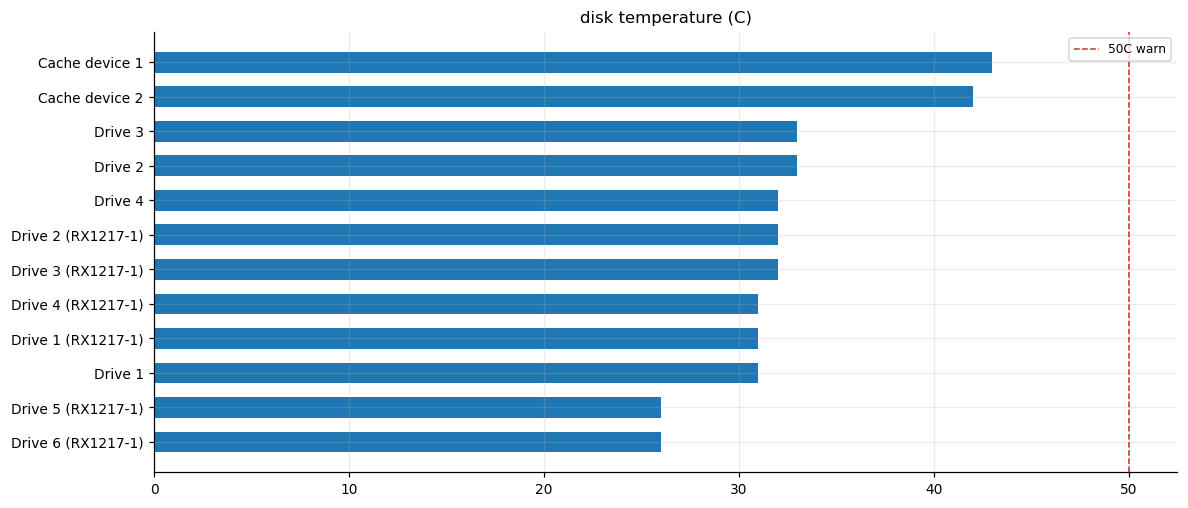

In [6]:
# --- DISKS: per-disk status/health/wear/temperature + SMART rollup ---
# remainLife = -1 means N/A (spinning disk); badSector = -1 means N/A (SSD). Do not read
# the -1 sentinel as a value. Synology rolls SMART into diskHealthStatus; we also surface
# the raw bad-sector / remaining-life / temperature the issue called out.
rows = []
for i in sorted(d_name, key=lambda x: int(x)):
    life, bad = d_life.get(i, -1), d_bad.get(i, -1)
    rows.append({'disk': d_name[i], 'model': d_model.get(i, ''), 'type': d_type.get(i, ''),
                 'status': DISK_STATUS.get(d_status.get(i), d_status.get(i)),
                 'health': DISK_HEALTH.get(d_health.get(i), d_health.get(i)),
                 'temp_C': d_temp.get(i, float('nan')),
                 'life_%': (float('nan') if life < 0 else life),
                 'bad_sec': ('-' if bad < 0 else int(bad)), 'retry': int(d_retry.get(i, 0))})
disk_df = pd.DataFrame(rows)
print(disk_df.to_string(index=False, float_format=lambda v: f'{v:,.0f}', na_rep='-'))
print(f"\nSMART: {smart_ok}/{smart_total} attributes OK across {len(set(smart_dev.values()))} devices"
      + ("" if not smart_bad_idx else ""))
if smart_bad_idx:
    print("  NOT OK:")
    for x in smart_bad_idx:
        print(f"    {smart_dev.get(x, '?')}  {smart_names.get(x, '?')}")

fig, ax = plt.subplots(figsize=(12, 0.35 * len(disk_df) + 1))
order = disk_df.sort_values('temp_C')
cols = ['C3' if t > disk_temp_warn_c else 'C0' for t in order['temp_C']]
ax.barh(order['disk'], order['temp_C'], color=cols, height=0.6)
ax.axvline(disk_temp_warn_c, color='C3', ls='--', lw=1, label=f'{disk_temp_warn_c}C warn')
ax.legend(fontsize=8)
ax.set_title('disk temperature (C)')
nbc.show(fig)

RAID / storage pools (Synology raidStatus; alloc% = space carved into volumes):
          name status   total  alloc_%  hotspare
      Volume 2 Normal 27.9TiB      7.5         0
Storage Pool 1 Normal 29.1TiB    100.0         0
      Volume 1 Normal 17.5TiB     66.7         0

volume fullness (node_exporter, top-level filesystems):
  /           84.1% full  (0GiB free of 2GiB)
  /volume1    66.7% full  (5.8TiB free of 17.5TiB)
  /volume2     7.5% full  (25.8TiB free of 27.9TiB)


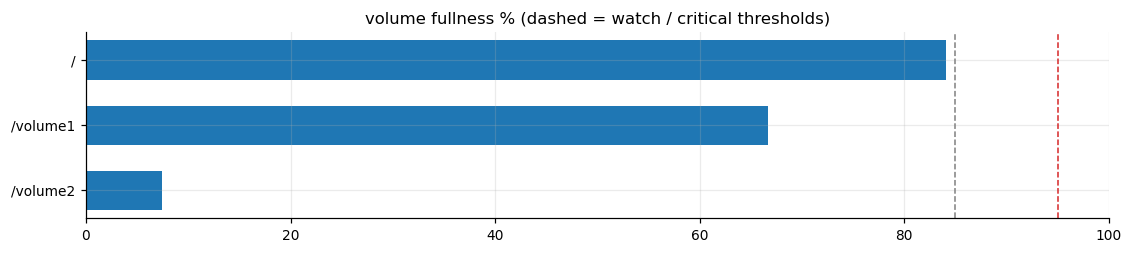

In [7]:
# --- STORAGE: RAID/pool status (Synology) + volume fullness (node_exporter) ---
# raidFreeSize/TotalSize is the POOL view: a pool fully carved into volumes reads ~0 free
# (alloc ~100%) -- that is normal, not "full". Real capacity headroom is the volume view
# (node_exporter) below.
def _sz(b):
    return f'{b / 2**40:.1f}TiB' if b >= 2**40 else f'{b / 2**30:.0f}GiB'

print("RAID / storage pools (Synology raidStatus; alloc% = space carved into volumes):")
rows = []
for i in sorted(r_status, key=lambda x: int(x)):
    tot, free = r_total.get(i, 0.0), r_free.get(i, 0.0)
    rows.append({'name': r_name.get(i, i), 'status': RAID_STATUS.get(int(r_status[i]), r_status[i]),
                 'total': _sz(tot), 'alloc_%': (100 * (1 - free / tot) if tot else float('nan')),
                 'hotspare': int(r_hs.get(i, 0))})
raid_df = pd.DataFrame(rows)
print(raid_df.to_string(index=False, float_format=lambda v: f'{v:,.1f}', na_rep='-') if not raid_df.empty else "  (none)")

# Volume fullness from node_exporter (top-level filesystems only: / and /volumeN, not the
# dozens of identical btrfs subvolume mounts that all report the parent volume's usage).
av = {r['metric'].get('mountpoint', ''): float(r['value'][1]) for r in fs_avail_res}
sz = {r['metric'].get('mountpoint', ''): float(r['value'][1]) for r in fs_size_res}
vol_full = {m: 100 * (1 - av[m] / sz[m]) for m in sz
            if sz[m] > 0 and (m == '/' or (m.startswith('/volume') and m.count('/') == 1))}
print("\nvolume fullness (node_exporter, top-level filesystems):")
for m in sorted(vol_full, key=lambda x: -vol_full[x]):
    print(f"  {m:<10} {vol_full[m]:5.1f}% full  ({_sz(av.get(m, 0))} free of {_sz(sz.get(m, 0))})")

fig, ax = plt.subplots(figsize=(12, 0.4 * len(vol_full) + 1))
if vol_full:
    ms = sorted(vol_full, key=lambda x: vol_full[x])
    cols = ['C3' if vol_full[m] >= vol_full_crit_pct else 'C1' if vol_full[m] >= vol_full_warn_pct else 'C0' for m in ms]
    ax.barh(ms, [vol_full[m] for m in ms], color=cols, height=0.6)
    ax.axvline(vol_full_warn_pct, color='0.5', ls='--', lw=1)
    ax.axvline(vol_full_crit_pct, color='C3', ls='--', lw=1)
    ax.set_xlim(0, 100)
ax.set_title('volume fullness % (dashed = watch / critical thresholds)')
nbc.show(fig)

UPS:
  model:   Tripp Lite UPS 
  status:  OL  (charge 100.0%, runtime 1863.0s, load 21.0%)
  line:    in 120.1V -> out 120.0V

OS resources (node_exporter):
  cpu:  5% busy over 5m (8 cores)
  load: 1m 1.41  (0.18 per core)
  mem:  11% used (3.4 / 31.1 GiB)
  board sensors (hwmon): 54C, 54C, 54C, 54C, 54C, 40C, 38C, 37C


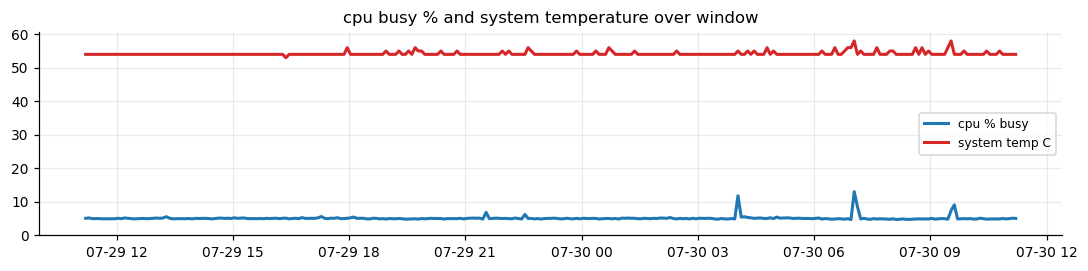

In [8]:
# --- UPS & OS RESOURCES ---
# UPS: upsInfoStatus is NUT-style ("OL"=on line, "OB"=on battery, "LB"=low battery,
# "RB"=replace battery). Runtime is seconds of battery at current load.
print("UPS:")
if ups:
    print(f"  model:   {ups_model or 'n/a'}")
    print(f"  status:  {ups.get('upsInfoStatus', '?')}  (charge {ups.get('upsBatteryChargeValue', '?')}%, "
          f"runtime {ups.get('upsBatteryRuntimeValue', '?')}s, load {ups.get('upsInfoLoadValue', '?')}%)")
    print(f"  line:    in {ups.get('upsInputVoltageValue', '?')}V -> out {ups.get('upsOutputVoltageValue', '?')}V")
else:
    print("  no UPS metrics present")
ups_stats = {'status': ups.get('upsInfoStatus'), 'battery_charge_pct': ups.get('upsBatteryChargeValue'),
             'battery_runtime_s': ups.get('upsBatteryRuntimeValue'), 'load_pct': ups.get('upsInfoLoadValue'),
             'input_v': ups.get('upsInputVoltageValue'), 'output_v': ups.get('upsOutputVoltageValue'),
             'model': ups_model}

mem_used_pct = 100 * (1 - mem_avail / mem_total) if mem_total else float('nan')
print(f"\nOS resources (node_exporter):")
print(f"  cpu:  {100 * cpu_busy:.0f}% busy over 5m ({ncpu:.0f} cores)")
print(f"  load: 1m {load1:.2f}  ({load1 / ncpu:.2f} per core)" if ncpu else f"  load: 1m {load1:.2f}")
print(f"  mem:  {mem_used_pct:.0f}% used ({(mem_total - mem_avail) / 2**30:.1f} / {mem_total / 2**30:.1f} GiB)")
if hwmon_temps:
    print(f"  board sensors (hwmon): {', '.join(f'{v:.0f}C' for v in sorted(hwmon_temps, reverse=True))}")

fig, ax = plt.subplots(figsize=(12, 2.4))
cb = f_cpu['value'] if not f_cpu.empty else pd.Series(dtype=float)
if cb.notna().any():
    ax.plot(cb.index, 100 * cb, color='C0', lw=2, label='cpu % busy')
    ax.plot(f_systemp.index, f_systemp['value'], color='C3', lw=2, label='system temp C') if not f_systemp.empty else None
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)
ax.set_title('cpu busy % and system temperature over window')
nbc.show(fig)

In [9]:
# --- SUMMARY: data-through gate passed (above), then the host-happiness verdict ---
# Findings are concrete unhappy conditions vs the chosen thresholds -- no invented
# "did the signal arrive" findings (that is the assumptions gate, not a finding here).
findings = []
for label, v in [('system', sys_status), ('power', power_status),
                 ('system fan', sys_fan), ('cpu fan', cpu_fan)]:
    if v != 1:
        findings.append(f"{label} status = {SYS_STATUS.get(v, v)} (expected Normal)")
if sys_temp > sys_temp_warn_c:
    findings.append(f"system temperature {sys_temp:.0f}C > {sys_temp_warn_c}C")

for i, name in d_name.items():
    st, h = d_status.get(i), d_health.get(i)
    if st is not None and st != 1:
        findings.append(f"disk {name}: status {DISK_STATUS.get(st, st)} (expected Normal)")
    if h is not None and h != 1:
        findings.append(f"disk {name}: health {DISK_HEALTH.get(h, h)} (expected Normal)")
    bad = d_bad.get(i, -1)               # -1 = N/A (SSD); >0 = reallocated bad sectors
    if bad is not None and bad > 0:
        findings.append(f"disk {name}: {int(bad)} bad sectors accumulating")
    life = d_life.get(i, -1)             # -1 = N/A (HDD); else SSD remaining-life %
    if life is not None and 0 <= life <= ssd_life_warn_pct:
        findings.append(f"disk {name}: SSD remaining life {life:.0f}% (<= {ssd_life_warn_pct}%)")
    t = d_temp.get(i)
    if t is not None and t > disk_temp_warn_c:
        findings.append(f"disk {name}: {t:.0f}C > {disk_temp_warn_c}C")
if smart_bad_idx:
    findings.append(f"SMART: {len(smart_bad_idx)}/{smart_total} attributes not OK: "
                    + ", ".join(f"{smart_dev.get(x, '?')}/{smart_names.get(x, '?')}" for x in smart_bad_idx[:8]))

for i, s in r_status.items():
    if int(s) != 1:
        sev = 'CRITICAL' if int(s) in (11, 12) else 'attention/transient'
        findings.append(f"volume/pool {r_name.get(i, i)}: status {RAID_STATUS.get(int(s), s)} ({sev})")
for m, pct in vol_full.items():
    if pct >= vol_full_crit_pct:
        findings.append(f"volume {m}: {pct:.0f}% full (>= {vol_full_crit_pct}% CRITICAL)")
    elif pct >= vol_full_warn_pct:
        findings.append(f"volume {m}: {pct:.0f}% full (>= {vol_full_warn_pct}% watch)")

ustat = str(ups.get('upsInfoStatus', ''))
if ustat and 'OL' not in ustat:
    findings.append(f"UPS status {ustat} (not on line power)")
if isinstance(ups.get('upsBatteryRuntimeValue'), (int, float)) and ups['upsBatteryRuntimeValue'] < ups_runtime_warn_s:
    findings.append(f"UPS battery runtime {ups['upsBatteryRuntimeValue']:.0f}s (< {ups_runtime_warn_s}s)")

if not np.isnan(mem_used_pct) and mem_used_pct > 90:
    findings.append(f"memory {mem_used_pct:.0f}% used")
if not np.isnan(load1) and not np.isnan(ncpu) and ncpu > 0 and load1 > 2 * ncpu:
    findings.append(f"load1 {load1:.1f} > 2x ncpu ({ncpu:.0f})")

print("=" * 64)
print("RACONTEUR HOST HEALTH SUMMARY")
print("=" * 64)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"host:     {edge_instance}  {model}  DSM {dsm_version}  up {uptime_d:.1f}d")
print(f"data:     SNMP {snmp_age:.0f}s / node_exporter {ne_age:.0f}s old (gate < {metric_stale_s}s) -- fresh")
print()
if findings:
    print(f"Findings ({len(findings)}):")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- disks/volumes Normal, SMART clean, temps/fans/power OK, UPS on line")
print()
print(f"  Environment: system={SYS_STATUS.get(sys_status, sys_status)} power={SYS_STATUS.get(power_status, power_status)} "
      f"fans={SYS_STATUS.get(sys_fan, sys_fan)}/{SYS_STATUS.get(cpu_fan, cpu_fan)} temp={sys_temp:.0f}C")
print(f"  Disks:       {len(d_name)} present, {sum(1 for v in d_status.values() if v == 1)} Normal; "
      f"SMART {smart_ok}/{smart_total} OK")
print(f"  Storage:     {sum(1 for s in r_status.values() if int(s) == 1)}/{len(r_status)} pools Normal; "
      f"fullest volume {max(vol_full.values()) if vol_full else float('nan'):.0f}%")
print(f"  UPS:         {ups.get('upsInfoStatus', 'n/a')} charge {ups.get('upsBatteryChargeValue', '?')}% "
      f"load {ups.get('upsInfoLoadValue', '?')}%")
print(f"  OS:          cpu {100 * cpu_busy:.0f}% busy, load1 {load1:.1f}/{ncpu:.0f}cpu, mem {mem_used_pct:.0f}% used")

RACONTEUR HOST HEALTH SUMMARY
run:      2026-07-30T11:12:06.912093+00:00  (live)
host:     raconteur  RS1619xs+  DSM 7.3-86009  up 4.9d
data:     SNMP 12s / node_exporter 45s old (gate < 900s) -- fresh

Findings (2):
  ! disk Drive 1: 16 bad sectors accumulating
  ! disk Cache device 2: SSD remaining life 18% (<= 20%)

  Environment: system=Normal power=Normal fans=Normal/Normal temp=54C
  Disks:       12 present, 12 Normal; SMART 207/207 OK
  Storage:     3/3 pools Normal; fullest volume 84%
  UPS:         OL charge 100.0% load 21.0%
  OS:          cpu 5% busy, load1 1.4/8cpu, mem 11% used


In [10]:
# AGENT-READABLE STATS -- consolidated JSON; assumption (data-through) status leads.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at, 'mode': cap.mode,
    'host': {'name': edge_instance, 'model': model, 'dsm': dsm_version, 'uptime_days': _n(uptime_d)},
    'assumptions': {'status': 'ok', 'data_through': 'fresh',
                    'instrument_age_s': {'mimir_up': _n(mimir_age),
                                         'snmp': _n(snmp_age), 'node_exporter': _n(ne_age)}},
    'findings': findings,
    'environment': {'system_status': SYS_STATUS.get(sys_status, sys_status),
                    'power_status': SYS_STATUS.get(power_status, power_status),
                    'system_fan': SYS_STATUS.get(sys_fan, sys_fan),
                    'cpu_fan': SYS_STATUS.get(cpu_fan, cpu_fan),
                    'system_temp_c': _n(sys_temp)},
    'disks': {n: {'model': d_model.get(i, ''), 'status': DISK_STATUS.get(d_status.get(i), d_status.get(i)),
                  'health': DISK_HEALTH.get(d_health.get(i), d_health.get(i)),
                  'temp_c': _n(d_temp.get(i)), 'remain_life_pct': (None if d_life.get(i, -1) < 0 else _n(d_life.get(i))),
                  'bad_sectors': (None if d_bad.get(i, -1) < 0 else int(d_bad.get(i, 0))),
                  'retry': int(d_retry.get(i, 0))}
              for i, n in d_name.items()},
    'smart': {'attrs_ok': smart_ok, 'attrs_total': smart_total,
              'not_ok': [f"{smart_dev.get(x, '?')}:{smart_names.get(x, '?')}" for x in smart_bad_idx]},
    'storage': {r_name.get(i, i): {'status': RAID_STATUS.get(int(s), s),
                                   'total_tib': _n(r_total.get(i, 0) / 2**40),
                                   'used_pct': _n(100 * (1 - r_free.get(i, 0) / r_total.get(i, 1)) if r_total.get(i, 0) else float('nan'))}
                for i, s in r_status.items()},
    'volumes_pct_full': {m: _n(v) for m, v in vol_full.items()},
    'ups': ups_stats,
    'os': {'cpu_busy_pct': _n(100 * cpu_busy), 'load1': _n(load1), 'ncpu': _n(ncpu),
           'mem_used_pct': _n(mem_used_pct)},
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "raconteur-health.ipynb",
 "run_at": "2026-07-30T11:12:06.912093+00:00",
 "mode": "live",
 "host": {
  "name": "raconteur",
  "model": "RS1619xs+",
  "dsm": "7.3-86009",
  "uptime_days": 4.9195
 },
 "assumptions": {
  "status": "ok",
  "data_through": "fresh",
  "instrument_age_s": {
   "mimir_up": 1.7511,
   "snmp": 11.8151,
   "node_exporter": 45.1741
  }
 },
 "findings": [
  "disk Drive 1: 16 bad sectors accumulating",
  "disk Cache device 2: SSD remaining life 18% (<= 20%)"
 ],
 "environment": {
  "system_status": "Normal",
  "power_status": "Normal",
  "system_fan": "Normal",
  "cpu_fan": "Normal",
  "system_temp_c": 54.0
 },
 "disks": {
  "Drive 1": {
   "model": "ST10000NE0004-1ZF101",
   "status": "Normal",
   "health": "Normal",
   "temp_c": 31.0,
   "remain_life_pct": null,
   "bad_sectors": 16,
   "retry": 0
  },
  "Drive 2": {
   "model": "ST10000NE0008-2PL103",
   "status": "Normal",
   "health": "Normal",
   "temp_c": 33.0,
   "remain_life_pct": null,
   "b